In [16]:
from sklearn.datasets import fetch_openml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
data = fetch_openml(data_id=44225, as_frame=True)
df = data.frame

In [27]:
df.shape
df.columns

Index(['MEMBERSHIP_NUMBER', 'MEMBERSHIP_TERM_YEARS', 'ANNUAL_FEES',
       'MEMBER_MARITAL_STATUS', 'MEMBER_GENDER', 'MEMBER_ANNUAL_INCOME',
       'MEMBER_OCCUPATION_CD', 'MEMBERSHIP_PACKAGE', 'MEMBER_AGE_AT_ISSUE',
       'ADDITIONAL_MEMBERS', 'PAYMENT_MODE', 'AGENT_CODE', 'MEMBERSHIP_STATUS',
       'START_DATE (YYYYMMDD)', 'END_DATE  (YYYYMMDD)'],
      dtype='str')

In [8]:
df['MEMBERSHIP_STATUS'].value_counts()

MEMBERSHIP_STATUS
INFORCE      7219
CANCELLED    3143
Name: count, dtype: int64

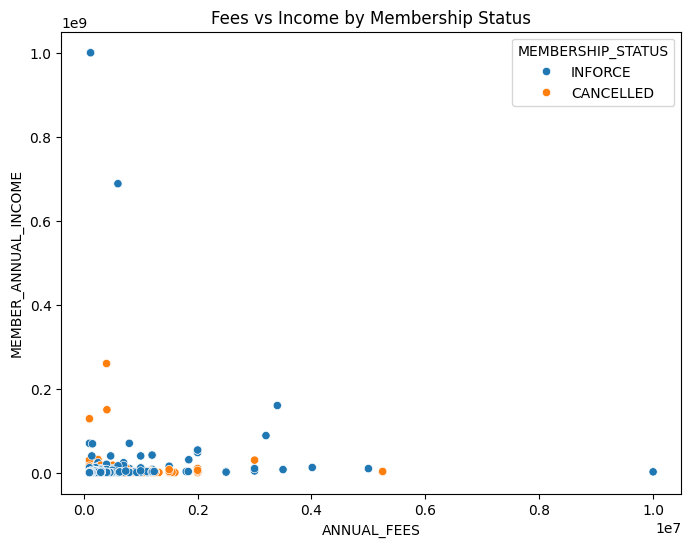

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='ANNUAL_FEES',
    y='MEMBER_ANNUAL_INCOME',
    hue='MEMBERSHIP_STATUS'
)

plt.title("Fees vs Income by Membership Status")
plt.show()

In [28]:
df = df.drop([
    'MEMBERSHIP_NUMBER',
    'AGENT_CODE',
    'START_DATE (YYYYMMDD)',
    'END_DATE  (YYYYMMDD)'
], axis=1)

In [29]:
df = df.dropna()

In [30]:
le = LabelEncoder()
y = df['MEMBERSHIP_STATUS']
X = df.drop('MEMBERSHIP_STATUS', axis=1)

# Encode categorical features
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

# Encode target
y = le.fit_transform(y)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100,max_depth=3,bootstrap=True,oob_score=True,random_state=42)
rf.fit(X_train, y_train)
print("OOB Score:", rf.oob_score_)

OOB Score: 1.0


c:\Users\suhas\OneDrive\Desktop\suhas_ml\my_env\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


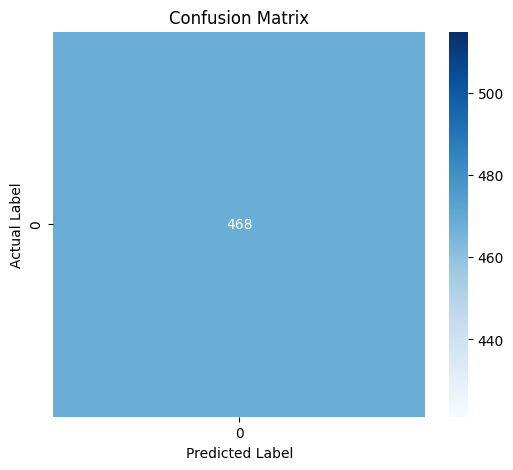

In [32]:
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       468

    accuracy                           1.00       468
   macro avg       1.00      1.00      1.00       468
weighted avg       1.00      1.00      1.00       468



In [34]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

top5 = importance.sort_values(ascending=False).head(5)
print(importance.sort_values(ascending=False))

MEMBERSHIP_TERM_YEARS    0.0
ANNUAL_FEES              0.0
MEMBER_MARITAL_STATUS    0.0
MEMBER_GENDER            0.0
MEMBER_ANNUAL_INCOME     0.0
MEMBER_OCCUPATION_CD     0.0
MEMBERSHIP_PACKAGE       0.0
MEMBER_AGE_AT_ISSUE      0.0
ADDITIONAL_MEMBERS       0.0
PAYMENT_MODE             0.0
dtype: float64


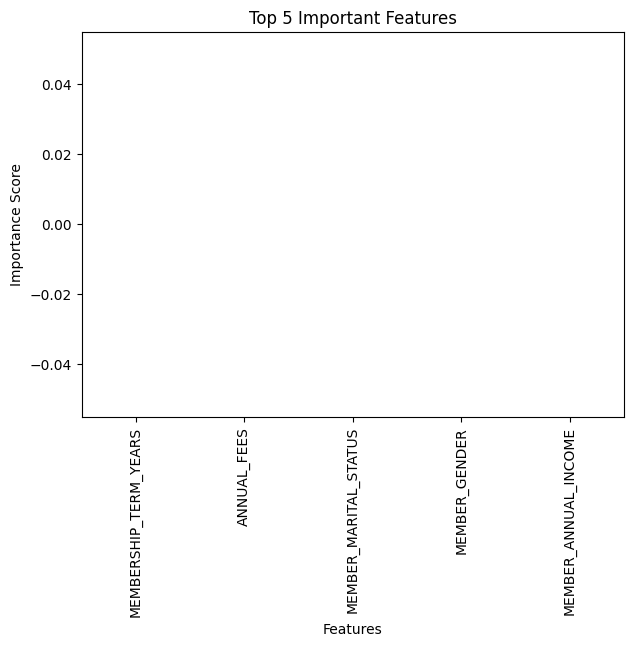

In [35]:
plt.figure(figsize=(7,5))
top5.plot(kind='bar')

plt.title("Top 5 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()